Slide dimensions: (97536, 95744)
Slide level count: 9
Slide level dimensions: ((97536, 95744), (48768, 47872), (24384, 23936), (12192, 11968), (6096, 5984), (3048, 2992), (1524, 1496), (762, 748), (381, 374))
Slide level downsamples: (1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0)
openslide.level-count: 9
openslide.level[0].downsample: 1
openslide.level[0].height: 95744
openslide.level[0].tile-height: 256
openslide.level[0].tile-width: 256
openslide.level[0].width: 97536
openslide.level[1].downsample: 2
openslide.level[1].height: 47872
openslide.level[1].tile-height: 256
openslide.level[1].tile-width: 256
openslide.level[1].width: 48768
openslide.level[2].downsample: 4
openslide.level[2].height: 23936
openslide.level[2].tile-height: 256
openslide.level[2].tile-width: 256
openslide.level[2].width: 24384
openslide.level[3].downsample: 8
openslide.level[3].height: 11968
openslide.level[3].tile-height: 256
openslide.level[3].tile-width: 256
openslide.level[3].width: 12192
openslide.le

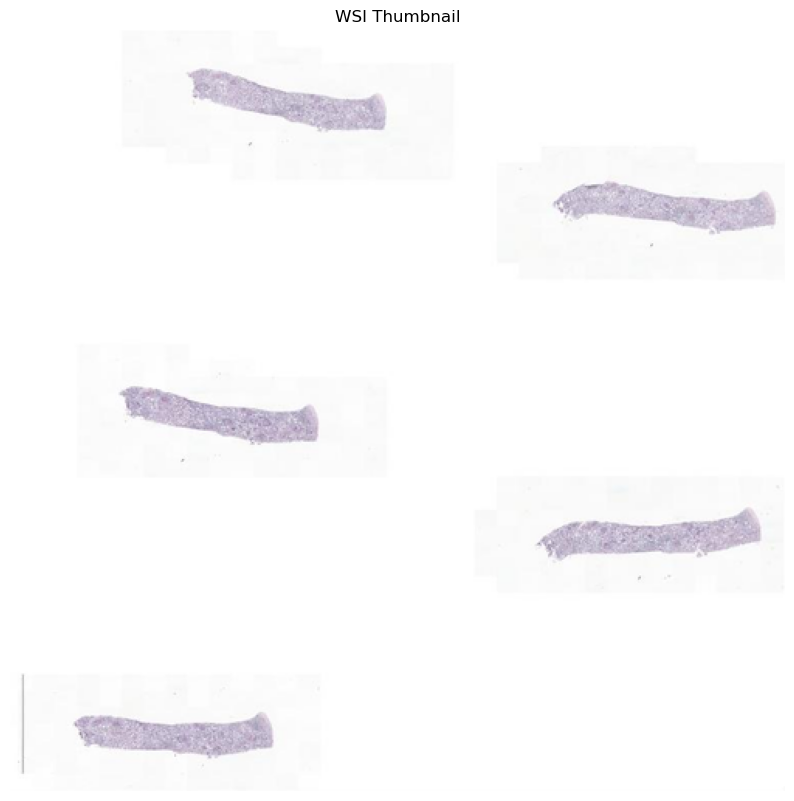

In [8]:
# debug_patch_extraction.ipynb
import sys
sys.path.append('../src')  # Add src directory to path

import matplotlib.pyplot as plt
import numpy as np
import openslide
import os
import cv2
import random
from PIL import ImageDraw, Image

# Load the WSI file
wsi_path = "../example_wsis/A_P000001_PAS_CPG.tif"
slide = openslide.OpenSlide(wsi_path)

# Print slide properties
print(f"Slide dimensions: {slide.dimensions}")
print(f"Slide level count: {slide.level_count}")
print(f"Slide level dimensions: {slide.level_dimensions}")
print(f"Slide level downsamples: {slide.level_downsamples}")
if hasattr(slide, "properties"):
    for k, v in slide.properties.items():
        print(f"{k}: {v}")

# Visualize a thumbnail of the whole slide
thumbnail = slide.get_thumbnail((500, 500))
plt.figure(figsize=(10, 10))
plt.imshow(thumbnail)
plt.title("WSI Thumbnail")
plt.axis('off')
plt.show()


In [10]:
def is_tissue_patch(patch_np, threshold=0.05):
    # HSV-based tissue filtering
    hsv = cv2.cvtColor(patch_np, cv2.COLOR_RGB2HSV)
    saturation = hsv[:, :, 1]
    value = hsv[:, :, 2]

    tissue_mask = (saturation > 20) & (value < 230)
    tissue_percentage = np.sum(tissue_mask) / (patch_np.shape[0] * patch_np.shape[1])
    return tissue_percentage > threshold


In [39]:
def extract_patches_from_wsi(wsi_path, patch_size=256, overlap=0.25, level=0, tissue_threshold=0.05, 
                            create_debug_images=True, debug_output_dir=None, num_patches=1000):
    """
    Extract random patches from tissue regions in a whole slide image (WSI)
    
    Args:
        wsi_path (str): Path to the WSI file
        patch_size (int): Size of the patches to extract
        overlap (float): Overlap between patches (0-1)
        level (int): WSI pyramid level to extract from
        tissue_threshold (float): Minimum tissue percentage threshold
        create_debug_images (bool): Whether to create debug overlay images
        debug_output_dir (str, optional): Directory to save debug images
        num_patches (int): Maximum number of patches to extract
        
    Returns:
        list: List of tissue patches as numpy arrays
    """
    # Create output directory if needed for debug images
    if create_debug_images:
        assert debug_output_dir is not None, "debug_output_dir must be provided when create_debug_images=True"
        os.makedirs(debug_output_dir, exist_ok=True)
    
    # Open the slide
    print(f"Opening slide: {wsi_path}")
    slide = openslide.OpenSlide(wsi_path)
    width, height = slide.level_dimensions[level]
    
    # Initialize tracking
    patches = []
    count = 0
    
    # Calculate downsample factor based on slide size
    scale_factor = 1 / 16 if create_debug_images else 1 / min(32, width // 4000)
    thumb_width = int(width * scale_factor)
    thumb_height = int(height * scale_factor)
    
    print(f"Creating thumbnail at resolution {thumb_width}x{thumb_height}")
    thumbnail = slide.get_thumbnail((thumb_width, thumb_height)).convert("RGB")
    thumbnail_np = np.array(thumbnail)
    
    # Create debug overlay image
    if create_debug_images:
        downsampled = thumbnail.copy()
        draw = ImageDraw.Draw(downsampled)
    
    # Apply tissue detection to thumbnail
    hsv = cv2.cvtColor(thumbnail_np, cv2.COLOR_RGB2HSV)
    saturation = hsv[:, :, 1]
    value = hsv[:, :, 2]
    tissue_mask = (saturation > 20) & (value < 230)
    
    # Optional: Clean up the mask with morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    tissue_mask = cv2.morphologyEx(tissue_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    tissue_mask = cv2.morphologyEx(tissue_mask, cv2.MORPH_CLOSE, kernel)
    
    # Save the tissue mask if in debug mode
    if create_debug_images:
        mask_path = os.path.join(debug_output_dir, "tissue_mask_thumbnail.png")
        Image.fromarray((tissue_mask * 255).astype(np.uint8)).save(mask_path)
        thumbnail.save(os.path.join(debug_output_dir, "thumbnail.png"))
    
    # Find coordinates of all tissue pixels in the thumbnail
    tissue_coords = np.where(tissue_mask)
    tissue_points = list(zip(tissue_coords[1], tissue_coords[0]))  # (x, y) format
    
    if not tissue_points:
        print("No tissue regions found in the slide")
        slide.close()
        return patches
    
    # Calculate thumbnail patch size for checking neighboring pixels
    thumb_patch_size = int(patch_size * scale_factor)
    
    # Randomly sample from tissue regions
    print(f"Randomly sampling up to {num_patches} patches from tissue regions")
    
    # Keep track of already sampled regions to avoid overlap
    sampled_regions = set()
    max_attempts = num_patches * 10  # Limit attempts to avoid infinite loop
    attempts = 0
    
    while count < num_patches and attempts < max_attempts:
        attempts += 1
        
        # Randomly select a tissue point from the mask
        if not tissue_points:
            break
            
        point_idx = np.random.randint(0, len(tissue_points))
        thumb_x, thumb_y = tissue_points[point_idx]
        
        # Check if we have enough space for a patch
        if (thumb_x + thumb_patch_size >= thumbnail_np.shape[1] or 
            thumb_y + thumb_patch_size >= thumbnail_np.shape[0]):
            continue
        
        # Verify this region has enough tissue
        region = tissue_mask[thumb_y:thumb_y+thumb_patch_size, thumb_x:thumb_x+thumb_patch_size]
        tissue_percentage = np.sum(region) / region.size
        
        if tissue_percentage <= tissue_threshold:
            continue
            
        # Map to full resolution coordinates
        full_x = int(thumb_x / scale_factor)
        full_y = int(thumb_y / scale_factor)
        
        # Create a region key to avoid overlap
        region_key = (full_x // (patch_size // 4), full_y // (patch_size // 4))
        if region_key in sampled_regions:
            continue
            
        sampled_regions.add(region_key)
        
        # Extract full resolution patch
        patch_pil = slide.read_region((full_x, full_y), level, (patch_size, patch_size)).convert("RGB")
        patch_np = np.array(patch_pil)
        
        # Final verification on the full resolution patch
        should_infer = is_tissue_patch(patch_np, tissue_threshold)
        
        if should_infer:
            patches.append(patch_np)
            print(f"Patch {count} at position x={full_x}, y={full_y} is a tissue patch")
            count += 1
        
        # Draw debug visualization
        if create_debug_images:
            rect = [
                thumb_x,
                thumb_y,
                thumb_x + thumb_patch_size,
                thumb_y + thumb_patch_size
            ]
            draw.rectangle(rect, outline="green" if should_infer else "red", width=1)
    
    # Save debug overlay
    if create_debug_images:
        debug_path = os.path.join(debug_output_dir, "patch_debug_overlay.png")
        downsampled.save(debug_path)
    
    print(f"Extracted {count} patches from {wsi_path} after {attempts} attempts")
    slide.close()
    return patches

In [40]:
# Define parameters for patch extraction
wsi_path = "../example_wsis/A_P000001_PAS_CPG.tif"  # Update this path to your slide file
patch_size = 256
overlap = 0.
level = 0
tissue_threshold = 0.05
debug_output_dir = "debug_output"
num_patches = 100
# Extract patches from the WSI
patches = extract_patches_from_wsi(
    wsi_path=wsi_path,
    patch_size=patch_size,
    overlap=overlap,
    level=level,
    tissue_threshold=tissue_threshold,
    create_debug_images=True,
    debug_output_dir=debug_output_dir,
    num_patches=num_patches
)

# Print some statistics
total_patches = len(patches)


print(f"Total patches extracted: {total_patches}")


for patch in patches:
    # normalize patch to 0-1
    patch = (patch - patch.min()) / (patch.max() - patch.min())
    # check patch isnt all ones or zeros
    if np.all(patch == 1) or np.all(patch == 0):
        continue
    
    print('min', patch.min(), 'max', patch.max())


Opening slide: ../example_wsis/A_P000001_PAS_CPG.tif
Creating thumbnail at resolution 6096x5984
Randomly sampling up to 100 patches from tissue regions
Patch 0 at position x=31984, y=49376 is a tissue patch
Patch 1 at position x=30256, y=14352 is a tissue patch
Patch 2 at position x=83104, y=23344 is a tissue patch
Patch 3 at position x=78864, y=63920 is a tissue patch
Patch 4 at position x=88720, y=65216 is a tissue patch
Patch 5 at position x=69536, y=62672 is a tissue patch
Patch 6 at position x=83248, y=62864 is a tissue patch
Patch 7 at position x=32688, y=88448 is a tissue patch
Patch 8 at position x=88512, y=23072 is a tissue patch
Patch 9 at position x=80416, y=22944 is a tissue patch
Patch 10 at position x=12928, y=89728 is a tissue patch
Patch 11 at position x=16768, y=45424 is a tissue patch
Patch 12 at position x=27680, y=7696 is a tissue patch
Patch 13 at position x=25168, y=49632 is a tissue patch
Patch 14 at position x=9376, y=87328 is a tissue patch
Patch 15 at position

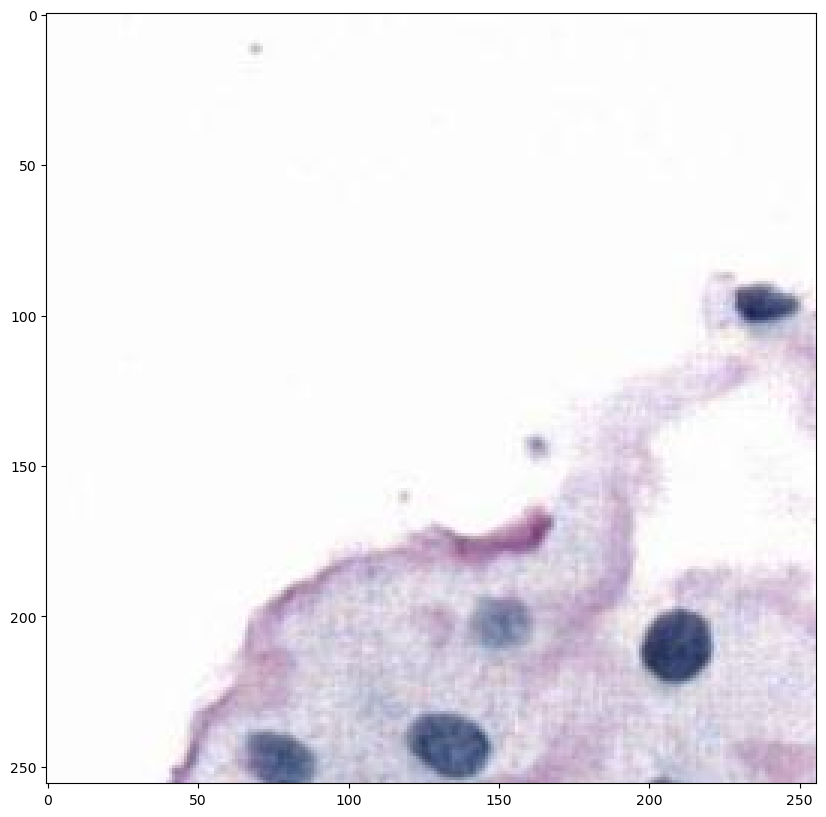

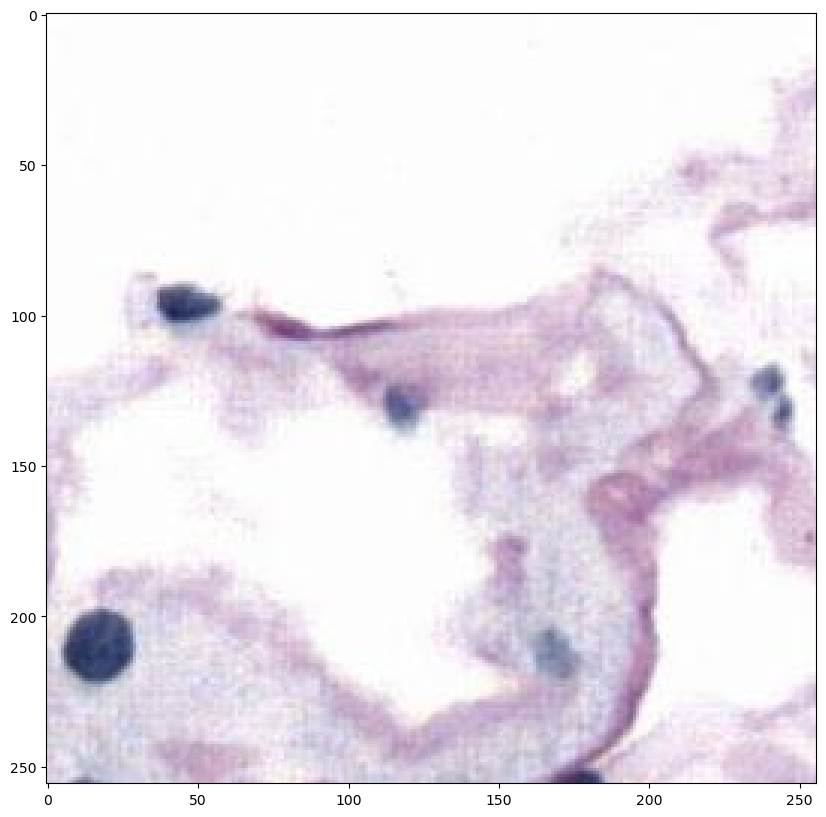

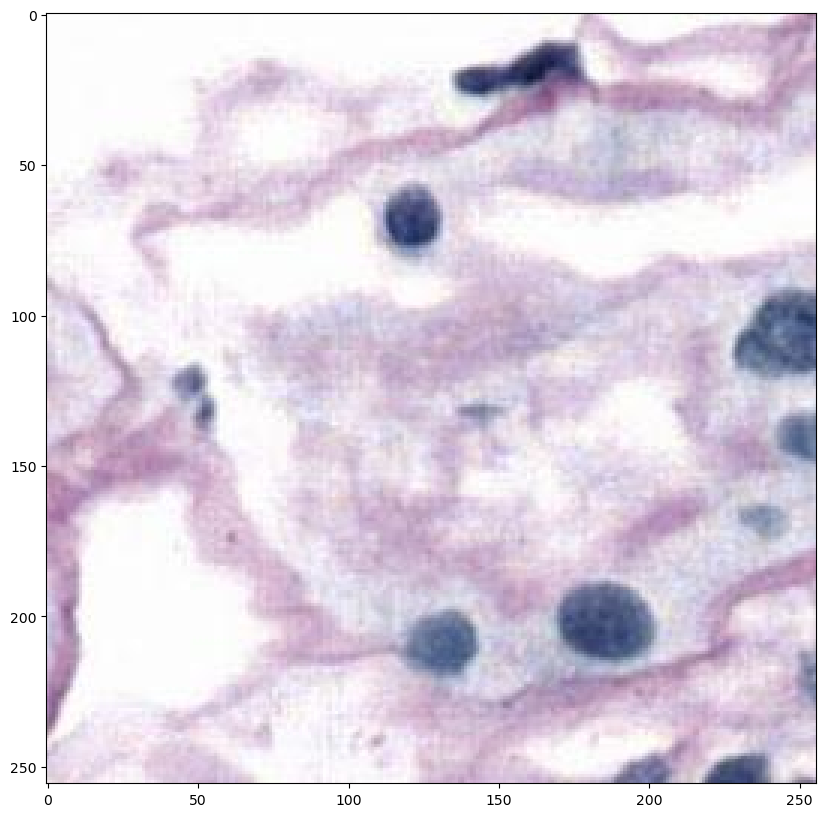

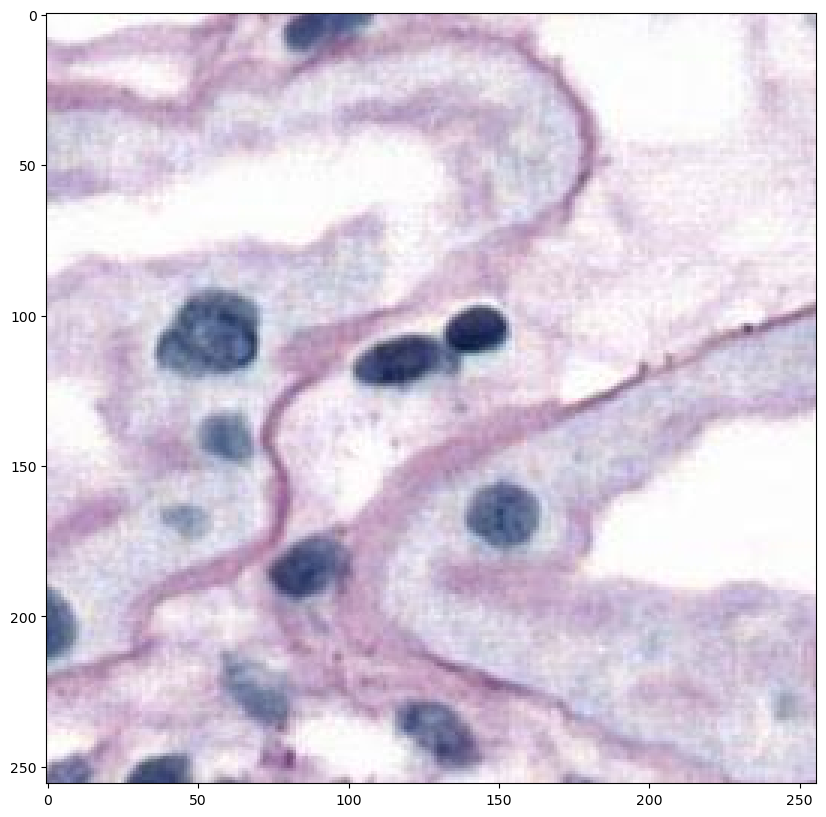

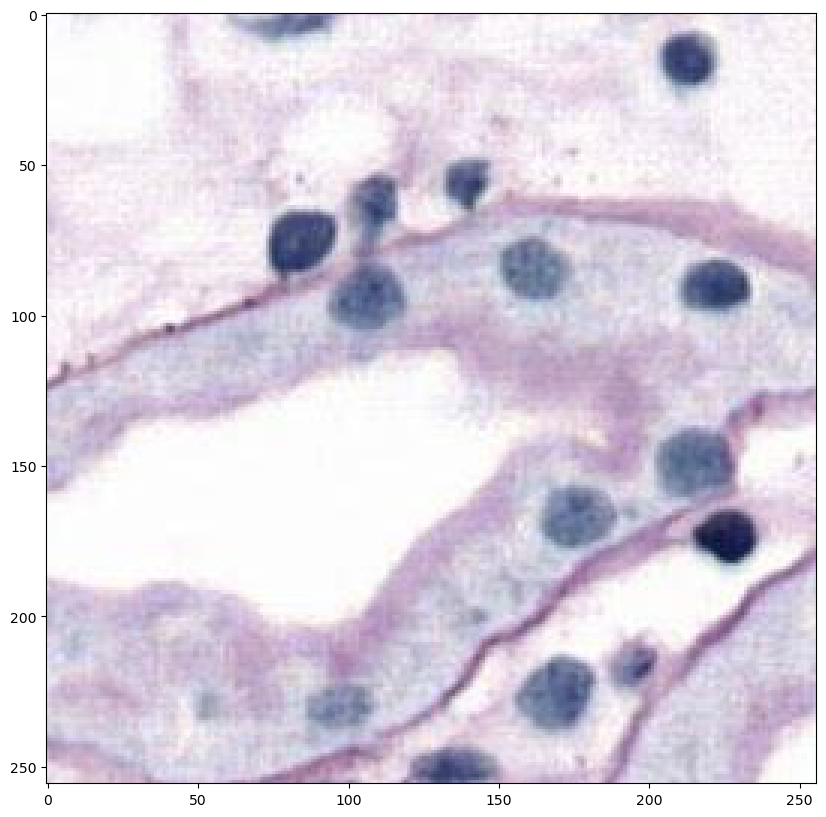

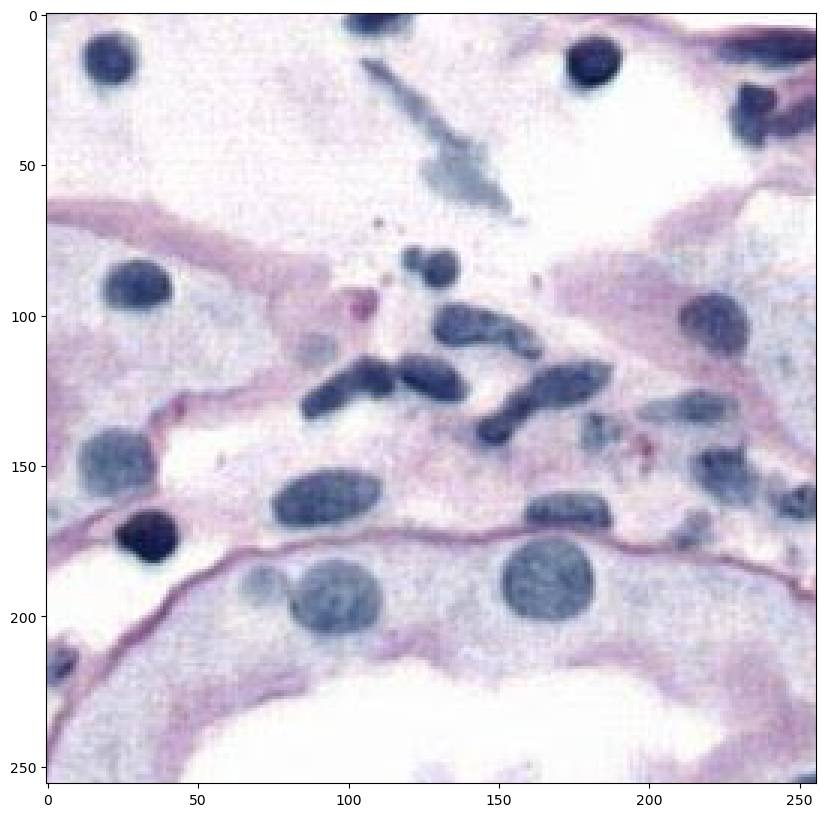

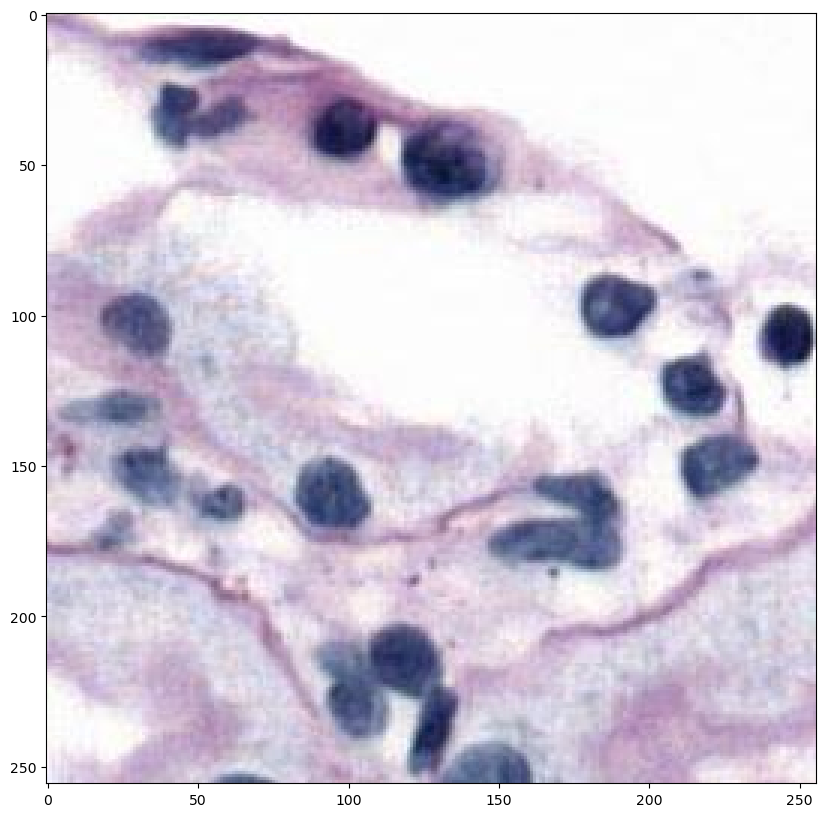

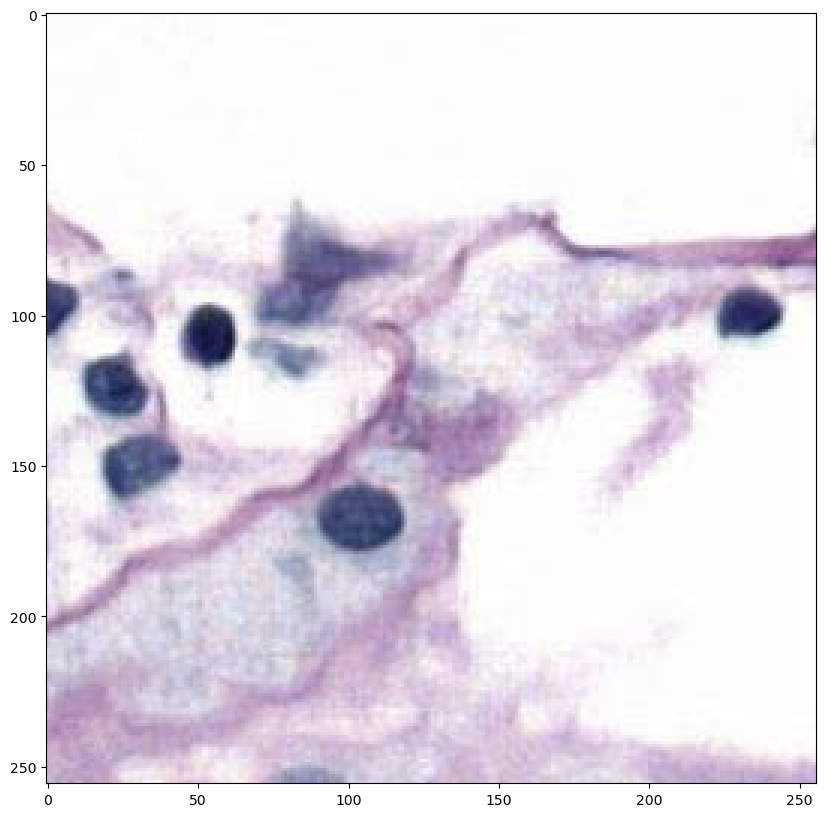

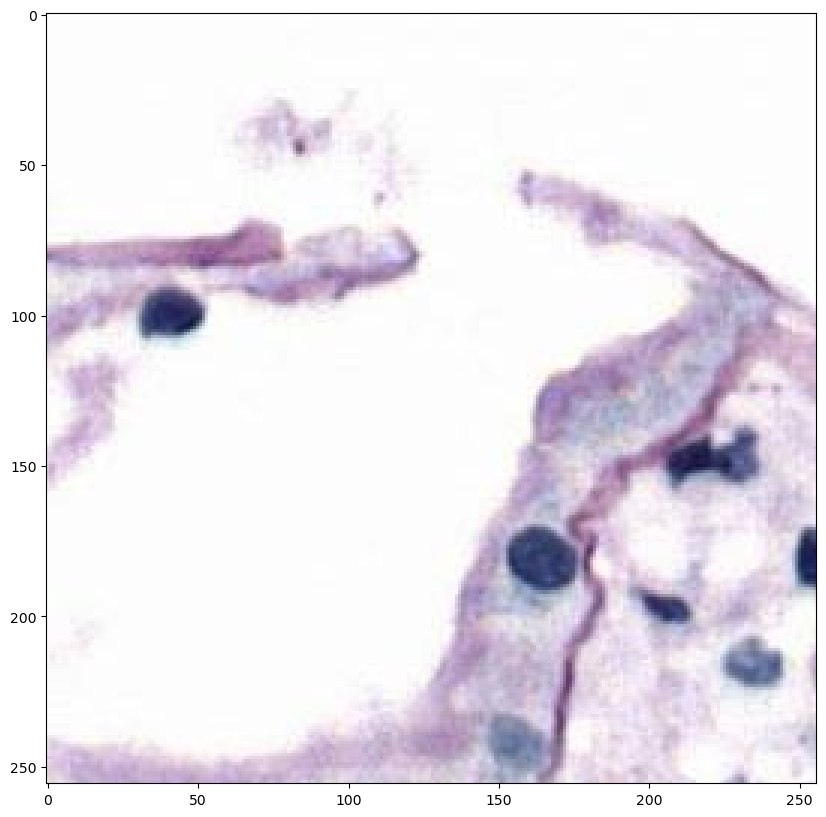

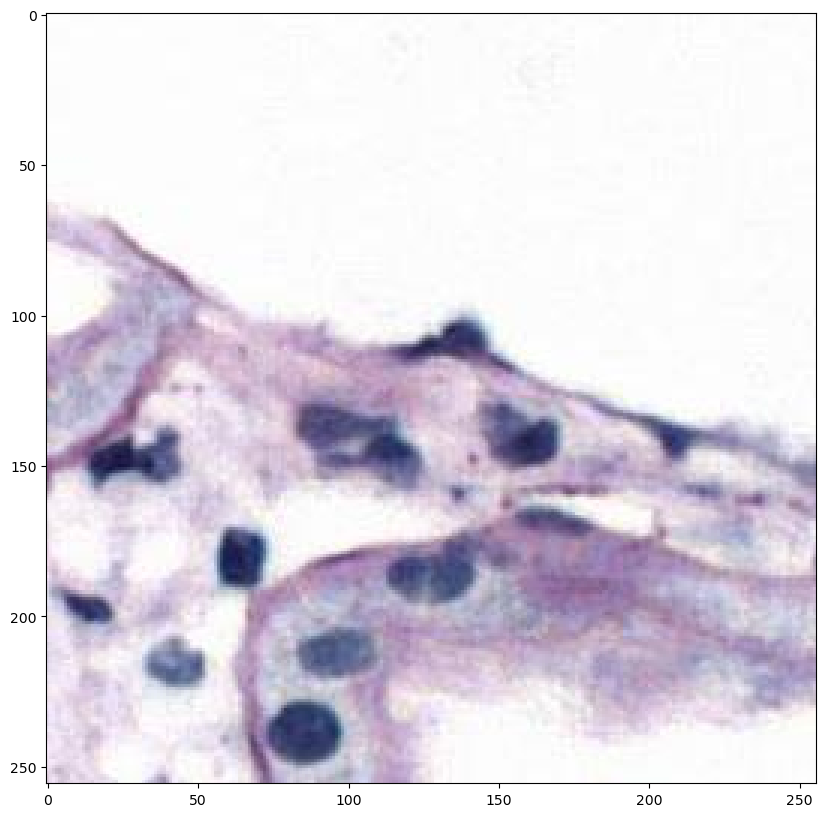

In [36]:
# Visualize all patches 
for patch in patches:
    plt.figure(figsize=(10, 10))
    plt.imshow(patch)
    plt.show()